## Pre-processing

In [2]:
import pandas as pd
import numpy as np
from google.colab import drive
from math import radians, cos, sin, asin, sqrt

# Mount Drive
drive.mount('/content/drive', force_remount=True)
path_drive = '/content/drive/MyDrive/Dataset_latihan/FP_MCI'

Mounted at /content/drive


In [3]:
# Load Data
df_orders = pd.read_csv(f'{path_drive}/orders.csv', parse_dates=['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'])
df_items = pd.read_csv(f'{path_drive}/order_items.csv')[['order_id', 'product_id', 'seller_id', 'freight_value', 'price']]

df_customers = pd.read_csv(f'{path_drive}/customers.csv')[['customer_id', 'customer_zip_code_prefix', 'customer_state']]
df_sellers = pd.read_csv(f'{path_drive}/sellers.csv')[['seller_id', 'seller_zip_code_prefix', 'seller_state']]

df_products = pd.read_csv(f'{path_drive}/products.csv')[['product_id', 'product_weight_g', 'product_category_name']]
df_reviews = pd.read_csv(f'{path_drive}/order_reviews.csv')[['order_id', 'review_score', 'review_comment_message']]

df_geo = pd.read_csv(f'{path_drive}/geolocation.csv', encoding='latin1')
df_geo_clean = df_geo.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

In [4]:
# Filter hanya pesanan 'delivered'
df_master = df_orders[df_orders['order_status'] == 'delivered'].copy()

# Merge data
df_master = df_master.merge(df_items, on='order_id', how='left')
df_master = df_master.merge(df_reviews.groupby('order_id').first().reset_index(), on='order_id', how='left')

df_master = df_master.merge(df_customers, on='customer_id', how='left')
df_master = df_master.merge(df_geo_clean, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')
df_master.rename(columns={'geolocation_lat': 'cust_lat', 'geolocation_lng': 'cust_lng'}, inplace=True)

df_master = df_master.merge(df_sellers, on='seller_id', how='left')
df_master = df_master.merge(df_geo_clean, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')
df_master.rename(columns={'geolocation_lat': 'seller_lat', 'geolocation_lng': 'seller_lng'}, inplace=True)

df_master = df_master.merge(df_products, on='product_id', how='left')

# Hapus baris tanpa tanggal kirim/koordinat dan hapus kolom zip yang tidak perlu
df_master.dropna(subset=['order_delivered_customer_date', 'order_approved_at', 'cust_lat', 'cust_lng'], inplace=True)
df_master.drop(columns=['geolocation_zip_code_prefix_x', 'geolocation_zip_code_prefix_y', 'customer_zip_code_prefix', 'seller_zip_code_prefix'], inplace=True)

In [5]:
from math import radians, cos, sin, asin, sqrt

# Fungsi Jarak
def calculate_distance(row):
    try:
        lon1, lat1, lon2, lat2 = map(radians, [row['seller_lng'], row['seller_lat'], row['cust_lng'], row['cust_lat']])
        return 6371 * (2 * asin(sqrt(sin((lat2 - lat1)/2)**2 + cos(lat1) * cos(lat2) * sin((lon2 - lon1)/2)**2)))
    except:
        return 0.0

df_master['distance_km'] = df_master.apply(calculate_distance, axis=1)

# Metrik Operasional
df_master['seller_process_days'] = (df_master['order_delivered_carrier_date'] - df_master['order_approved_at']).dt.total_seconds() / 86400
df_master['carrier_transit_days'] = (df_master['order_delivered_customer_date'] - df_master['order_delivered_carrier_date']).dt.total_seconds() / 86400
df_master['actual_delivery_time'] = (df_master['order_delivered_customer_date'] - df_master['order_purchase_timestamp']).dt.total_seconds() / 86400
df_master['is_late'] = (df_master['order_delivered_customer_date'] > df_master['order_estimated_delivery_date']).astype(int)
df_master['days_delayed'] = (df_master['order_delivered_customer_date'] - df_master['order_estimated_delivery_date']).dt.total_seconds() / 86400
df_master['days_delayed'] = df_master['days_delayed'].clip(lower=0)

# Metrik Biaya
df_master['cost_per_km'] = df_master.apply(lambda x: x['freight_value'] / x['distance_km'] if x['distance_km'] > 0 else 0, axis=1)

# Segmentasi Seller Besar
seller_counts = df_master['seller_id'].value_counts()
big_sellers = seller_counts[seller_counts > 500].index
df_master['seller_type'] = df_master['seller_id'].apply(lambda x: 'Seller Besar' if x in big_sellers else 'Seller UMKM')

# Kategori Berat
df_master['weight_class'] = df_master['product_weight_g'].apply(lambda x: 'Ringan (<1kg)' if x <= 1000 else ('Sedang (1-5kg)' if x <= 5000 else 'Berat (>5kg)'))

In [ ]:
# Simpan CSV
from google.colab import files
df_master.to_csv('master_operational_data.csv', index=False)
files.download('master_operational_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Post-Analysis

In [6]:
df_master.shape
df_master.info()
df_master.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 109886 entries, 0 to 110196
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       109886 non-null  object        
 1   customer_id                    109886 non-null  object        
 2   order_status                   109886 non-null  object        
 3   order_purchase_timestamp       109886 non-null  datetime64[ns]
 4   order_approved_at              109886 non-null  datetime64[ns]
 5   order_delivered_carrier_date   109885 non-null  datetime64[ns]
 6   order_delivered_customer_date  109886 non-null  datetime64[ns]
 7   order_estimated_delivery_date  109886 non-null  datetime64[ns]
 8   product_id                     109886 non-null  object        
 9   seller_id                      109886 non-null  object        
 10  freight_value                  109886 non-null  float64       
 11  price

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,freight_value,price,review_score,cust_lat,cust_lng,seller_lat,seller_lng,product_weight_g,distance_km,seller_process_days,carrier_transit_days,actual_delivery_time,is_late,days_delayed,cost_per_km
count,109886,109886,109885,109886,109886,109886.000000,109886.000000,109060.000000,109886.000000,109886.000000,109638.000000,109638.000000,109868.000000,109638.000000,109885.000000,109885.000000,109886.000000,109886.000000,109886.000000,109886.000000
mean,2018-01-02 03:00:56.840889856,2018-01-02 13:32:02.293458432,2018-01-05 09:50:29.975574272,2018-01-14 14:08:54.926469632,2018-01-25 22:10:11.062374144,19.942516,119.967485,4.082147,-21.246244,-46.216015,-22.798662,-47.239988,2090.381421,596.252769,2.845288,9.179954,12.463867,0.079036,0.744453,0.162013
min,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,0.000000,0.850000,1.000000,-33.689948,-72.668881,-32.079231,-63.893565,0.000000,0.000000,-171.219005,-16.096169,0.533414,0.000000,0.000000,0.000000
25%,2017-09-15 09:09:52.500000,2017-09-15 14:55:25.500000,2017-09-18 22:47:49,2017-09-26 20:27:56,2017-10-06 00:00:00,13.070000,39.900000,4.000000,-23.592368,-48.125102,-23.607690,-48.829744,300.000000,185.211728,0.881493,4.057118,6.727862,0.000000,0.000000,0.024359
50%,2018-01-21 08:37:51.500000,2018-01-22 13:55:26,2018-01-24 18:44:33,2018-02-02 20:51:58,2018-02-16 00:00:00,16.250000,74.900000,5.000000,-22.929564,-46.634985,-23.425556,-46.750602,700.000000,431.940673,1.834572,7.056701,10.179016,0.000000,0.000000,0.040854
75%,2018-05-05 16:05:17.750000128,2018-05-05 23:06:10.500000,2018-05-08 14:21:00,2018-05-15 20:08:46.249999872,2018-05-28 00:00:00,21.150000,134.170000,5.000000,-20.182732,-43.667690,-21.757321,-46.518679,1800.000000,791.642484,3.633403,11.902407,15.521615,0.000000,0.000000,0.088471
max,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,409.680000,6735.000000,5.000000,42.184003,-8.723762,-2.501242,-34.855616,40425.000000,8677.911622,125.762569,205.190972,209.628611,1.000000,188.975081,151.604741
std,NaN,NaN,NaN,NaN,NaN,15.701918,182.341189,1.346971,5.558325,4.034382,2.703431,2.341298,3742.683719,588.537936,3.580918,8.621695,9.442474,0.269797,4.639520,0.831572


In [7]:
missing = (
    df_master.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

,0
review_comment_message,64048
product_category_name,1531
review_score,826
distance_km,248
seller_lng,248
seller_lat,248
product_weight_g,18
seller_process_days,1
carrier_transit_days,1
order_delivered_carrier_date,1


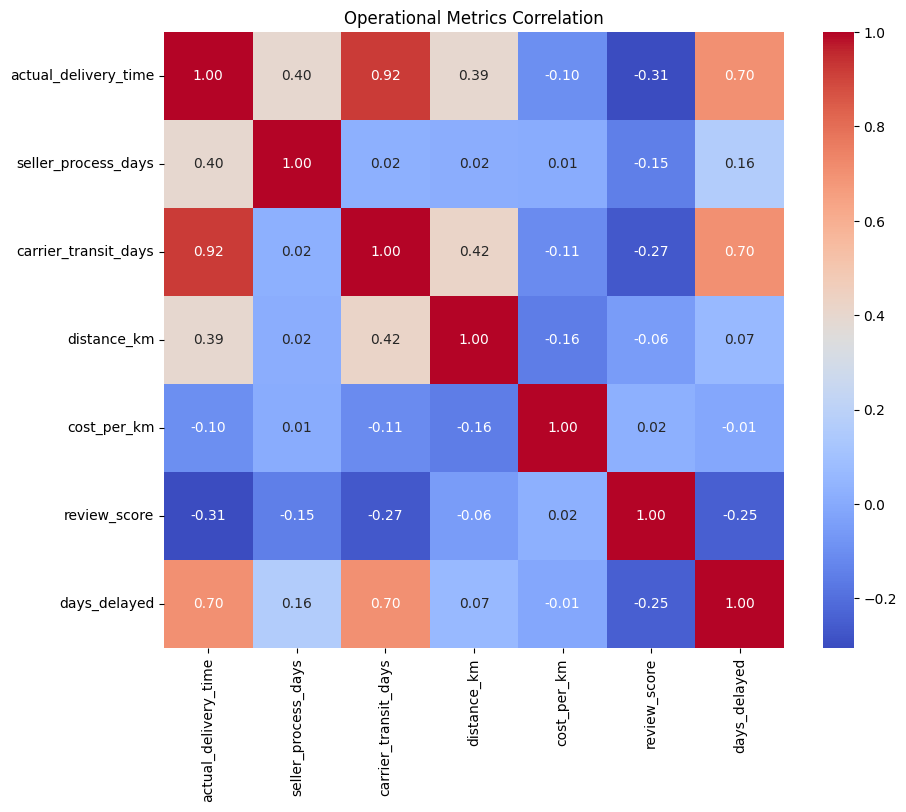

In [9]:
numeric_cols = [
    'actual_delivery_time',
    'seller_process_days',
    'carrier_transit_days',
    'distance_km',
    'cost_per_km',
    'review_score',
    'days_delayed'
]

corr = df_master[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Operational Metrics Correlation')
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


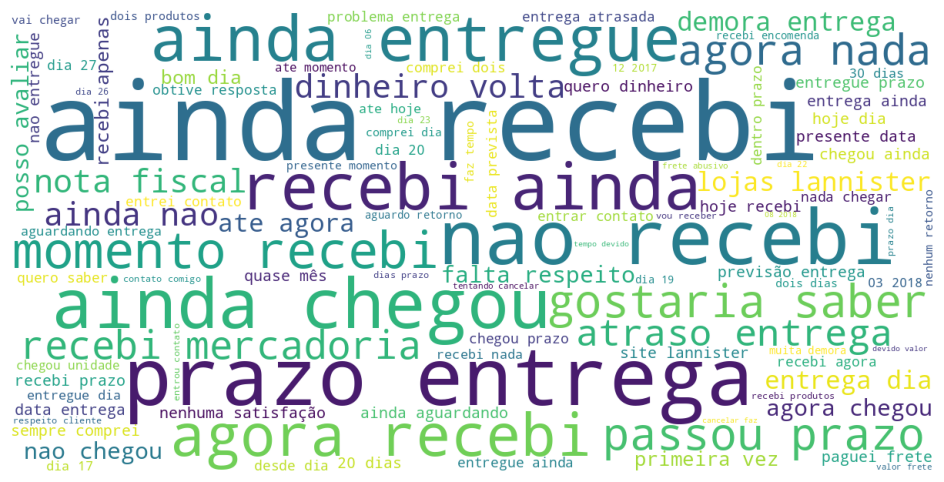

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

portuguese_stopwords = stopwords.words('portuguese')
custom_stopwords = portuguese_stopwords + [
    'produto',
    'loja',
    'compra',
    'pedido'
]

negative_reviews = df_master[
    (df_master['review_score'] <= 2)
    &
    (df_master['is_late'] == 1)
    &
    (df_master['review_comment_message'].notna())
]

texts = negative_reviews['review_comment_message'].astype(str)

vectorizer = TfidfVectorizer(
    stop_words=custom_stopwords,
    ngram_range=(2, 2),
    max_features=100
)

X = vectorizer.fit_transform(texts)

words = vectorizer.get_feature_names_out()
scores = X.sum(axis=0).A1

freq = dict(zip(words, scores))

wc = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate_from_frequencies(freq)

plt.figure(figsize=(14,6))
plt.imshow(wc)
plt.axis('off')
plt.show()

In [58]:
seller_state_perf[
    ['seller_state','total_orders','late_rate']
].sort_values(
    'total_orders',
    ascending=False,
)

,seller_state,total_orders,late_rate
21,SP,78368,8.514955
7,MG,8580,5.559441
14,PR,8473,6.443999
15,RJ,4670,8.137045
19,SC,3996,5.880881
18,RS,2164,4.482440
3,DF,881,6.696935
1,BA,619,5.331179
5,GO,506,3.952569
12,PE,444,4.054054


--2026-06-10 07:47:50--  https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3378231 (3.2M) [text/plain]
Saving to: ‘brazil-states.geojson.5’

brazil-states.geojs 100%[===================>]   3.22M  --.-KB/s    in 0.02s   

2026-06-10 07:47:51 (197 MB/s) - ‘brazil-states.geojson.5’ saved [3378231/3378231]



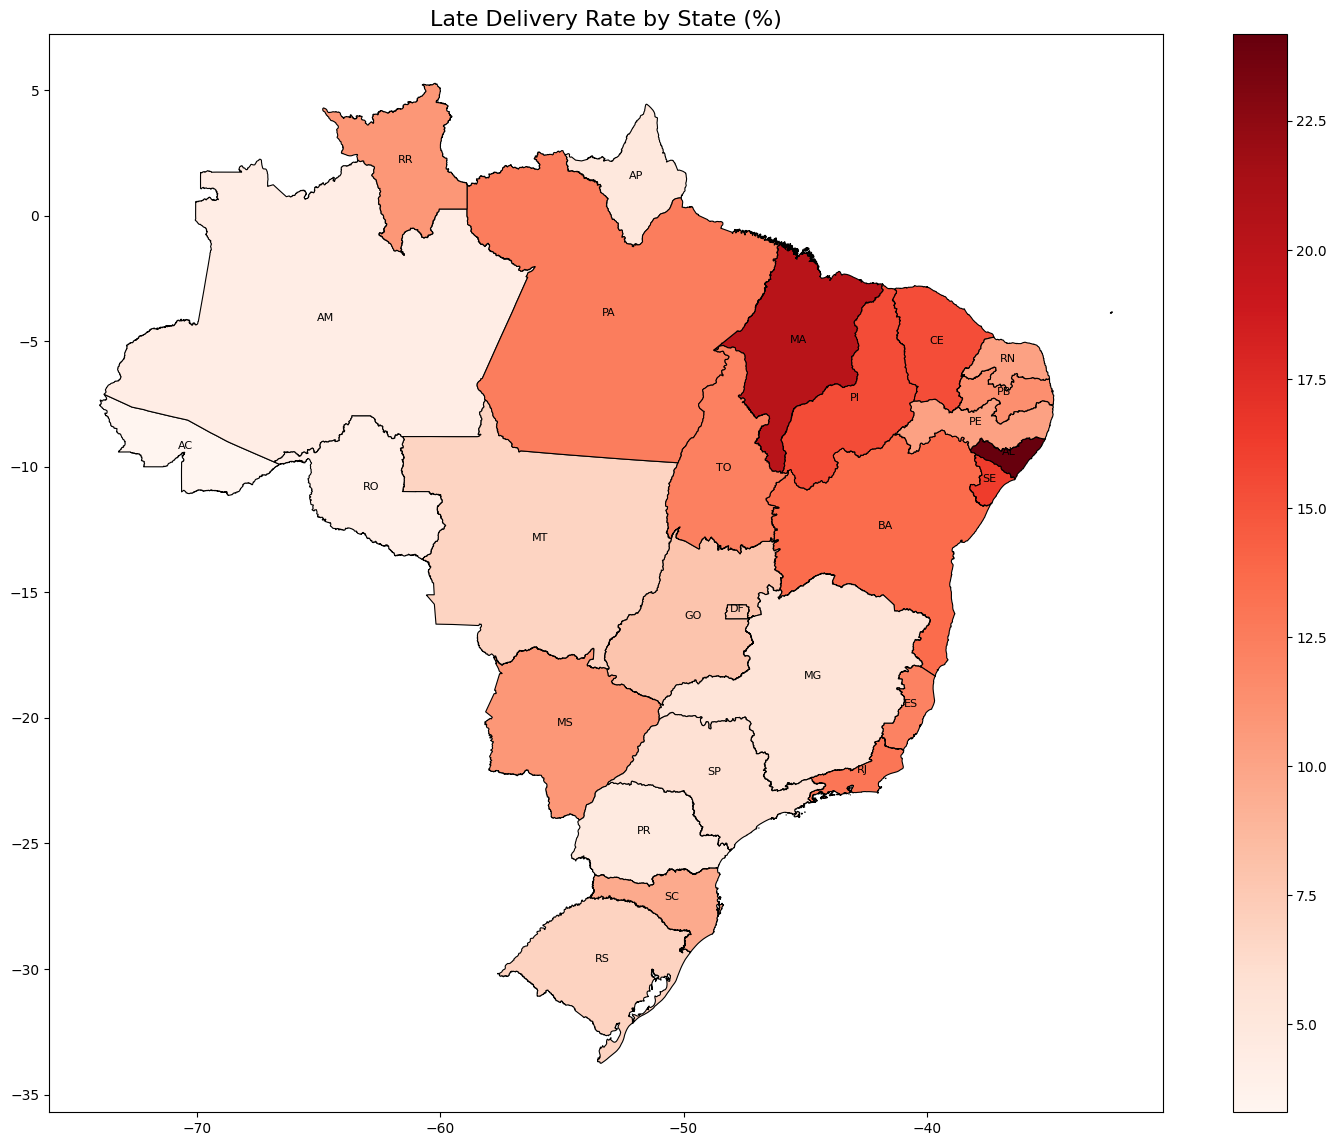

In [38]:
!wget https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson

import geopandas as gpd


brazil_map = gpd.read_file("brazil-states.geojson")

state_perf.head()
brazil_map = brazil_map.merge(
    state_perf,
    left_on='sigla',
    right_on='customer_state',
    how='left'
)

fig, ax = plt.subplots(
    1,
    1,
    figsize=(18,14)
)

brazil_map.plot(
    column='late_rate',
    cmap='Reds',
    linewidth=0.8,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.set_title(
    'Late Delivery Rate by State (%)',
    fontsize=16
)

for idx, row in brazil_map.iterrows():
    plt.annotate(
        text=row['sigla'],
        xy=(row.geometry.centroid.x,
            row.geometry.centroid.y),
        ha='center',
        fontsize=8
    )

plt.show()


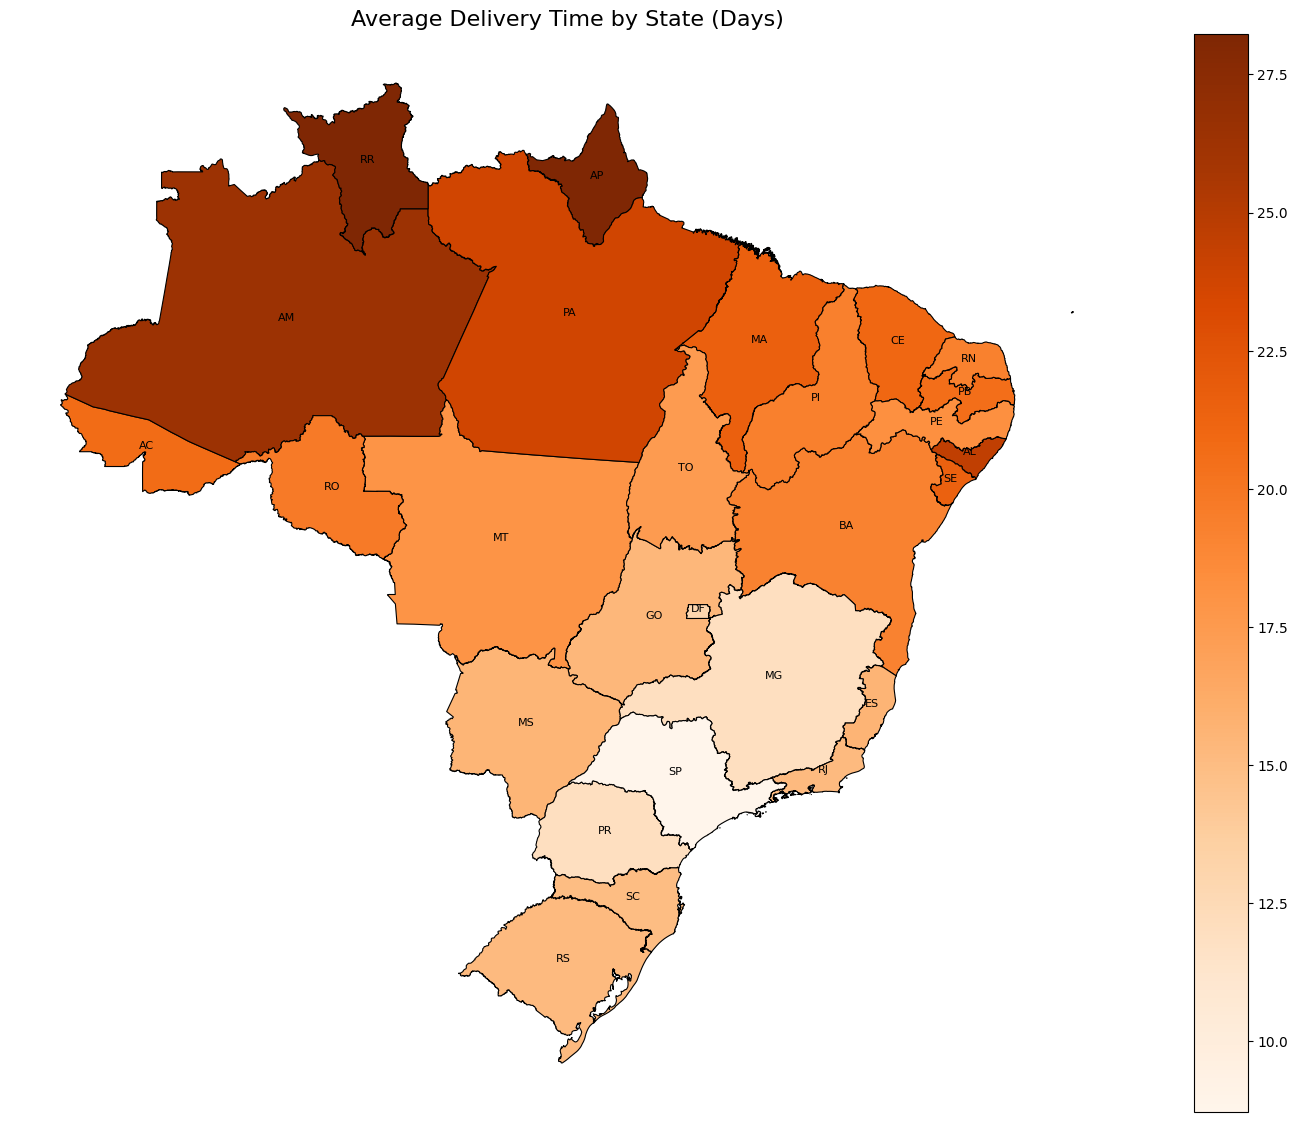

In [45]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(18,14)
)

brazil_map.plot(
    column='actual_delivery_time',
    cmap='Oranges',
    linewidth=0.8,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.set_title(
    'Average Delivery Time by State (Days)',
    fontsize=16
)

ax.axis('off')

for idx, row in brazil_map.iterrows():
    plt.annotate(
        text=row['sigla'],
        xy=(row.geometry.centroid.x,
            row.geometry.centroid.y),
        ha='center',
        fontsize=8
    )

plt.show()